In [1]:
import pandas as pd 
import helpers as h 
import constants as c
h.latex(True)

2025-12-01 12:37:47 - analysis-helpers - INFO - Enabling LaTeX for matplotlib.


In [2]:
nyc311_flooding_sep29 = pd.read_csv("../../aggregation/flooding/data/nyc311_flooding_sep29.csv")

In [3]:
nyc311_flooding_sep29

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,58965311,2023-09-29T23:53:00.000,2023-09-30T01:40:00.000,DEP,Department of Environmental Protection,Sewer,Sewer Backup (Use Comments) (SA),NaN,11207.0,339 WYONA STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.670462,-73.892554,"\n, \n(40.670461855689496, -73.89255367003082)"
1,58957633,2023-09-29T23:47:00.000,2023-09-30T12:15:00.000,DEP,Department of Environmental Protection,Sewer,Sewer Backup (Use Comments) (SA),NaN,11364.0,57-44 229 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.753306,-73.750132,"\n, \n(40.75330575318301, -73.7501324133223)"
2,58966873,2023-09-29T23:38:00.000,2023-09-30T04:40:00.000,DEP,Department of Environmental Protection,Sewer,Sewer Backup (Use Comments) (SA),NaN,11694.0,109-34 ROCKAWAY BEACH BOULEVARD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.581468,-73.831265,"\n, \n(40.58146791395729, -73.83126548969187)"
3,58959205,2023-09-29T23:38:00.000,2023-09-30T00:59:00.000,DEP,Department of Environmental Protection,Sewer,Street Flooding (SJ),NaN,11218.0,11 EAST 10 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.648040,-73.970598,"\n, \n(40.648039502907295, -73.97059787328804)"
4,58963762,2023-09-29T23:38:00.000,2023-09-30T13:00:00.000,DEP,Department of Environmental Protection,Sewer,Street Flooding (SJ),NaN,11420.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.664919,-73.822631,"\n, \n(40.66491867378627, -73.82263052827594)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,58945925,2023-09-28T08:23:00.000,2023-09-29T06:40:00.000,DEP,Department of Environmental Protection,Sewer,Catch Basin Clogged/Flooding (Use Comments) (SC),NaN,11233.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.683770,-73.926241,"\n, \n(40.683770352343984, -73.92624075847945)"
2189,58945926,2023-09-28T08:02:00.000,2023-09-29T22:55:00.000,DEP,Department of Environmental Protection,Sewer,Catch Basin Clogged/Flooding (Use Comments) (SC),NaN,11231.0,127 3 PLACE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.678425,-73.996726,"\n, \n(40.67842516994581, -73.99672640096483)"
2190,58945920,2023-09-28T07:23:00.000,2023-09-28T09:54:00.000,DEP,Department of Environmental Protection,Sewer,Catch Basin Clogged/Flooding (Use Comments) (SC),NaN,10467.0,2996 HOLLAND AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.869553,-73.865259,"\n, \n(40.86955314385188, -73.86525922168619)"
2191,58947189,2023-09-28T06:47:00.000,2023-09-28T09:50:00.000,DEP,Department of Environmental Protection,Sewer,Sewer Backup (Use Comments) (SA),NaN,11207.0,565 LIVONIA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.664416,-73.896352,"\n, \n(40.664415846690396, -73.89635177073404)"


In [4]:
nyc311_flooding_sep29['descriptor'].value_counts()

descriptor
Sewer Backup (Use Comments) (SA)                    1080
Street Flooding (SJ)                                 632
Catch Basin Clogged/Flooding (Use Comments) (SC)     433
Manhole Overflow (Use Comments) (SA1)                 37
Highway Flooding (SH)                                 11
Name: count, dtype: int64

In [5]:
# earliest and latest time 
nyc311_flooding_sep29['created_date'] = pd.to_datetime(nyc311_flooding_sep29['created_date'])
nyc311_flooding_sep29['closed_date'] = pd.to_datetime(nyc311_flooding_sep29['closed_date'])
print(nyc311_flooding_sep29['created_date'].min(), nyc311_flooding_sep29['created_date'].max())

2023-09-28 05:44:00 2023-09-29 23:53:00


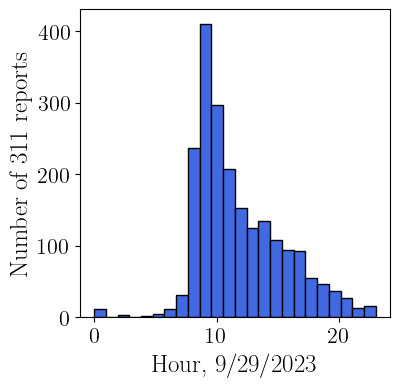

In [6]:
# histogram of 311 reports by time, but filter for ones on sep 29 
nyc311_flooding_sep29 = nyc311_flooding_sep29[nyc311_flooding_sep29['created_date'].dt.date == pd.to_datetime('2023-09-29').date()]

import matplotlib.pyplot as plt 
fig, ax = plt.subplots(figsize=(4,4))

nyc311_flooding_sep29['created_date'].dt.hour.hist(bins=24, ax=ax, edgecolor='black', color='royalblue')
plt.xlabel('Hour, 9/29/2023', fontsize=18)
plt.ylabel('Number of 311 reports', fontsize=18)

# set x and y ticks font size 
ax.tick_params(axis='both', which='major', labelsize=16)


# no grid 
ax.grid(False)

plt.savefig(f"{c.PAPER_PATH}/figures/nyc311_flooding_sep29_hourly_histogram.pdf", bbox_inches='tight', dpi=200)



In [7]:
# Load catch basins data
import geopandas as gpd
catch_basins = gpd.read_file("../../aggregation/flooding/static/catch_basins_nyc.geojson")
print(f"Total catch basins in NYC: {len(catch_basins):,}")
catch_basins.head()


Total catch basins in NYC: 151,839


,latitude,unitid,point_y,longitude,point_x,geometry
0,40.74655055,CB422067,211333.98343062,-73.7913729,1042057.84743,POINT (-73.79137 40.74655)
1,40.70289618,CB448880,195464.38829805,-73.74380019,1055286.1058,POINT (-73.7438 40.7029)
2,40.78722314,CB419775,226158.3661793,-73.78238563,1044511.28358,POINT (-73.78239 40.78722)
3,40.68103691,CB402038,187452.08653264,-73.81267426,1036206.56864,POINT (-73.81267 40.68104)
4,40.58184005,CB511457,151276.098566,-74.11131613,953329.472971,POINT (-74.11132 40.58184)


In [8]:
# Load clogged catch basin 311 complaints (June-September 2023)
clogged_cb_311 = pd.read_csv("../../aggregation/flooding/data/nyc311_clogged_cb_jun_sep.csv")
print(f"Total clogged catch basin 311 complaints (Jun 1 - Sep 29, 2023): {len(clogged_cb_311):,}")
clogged_cb_311.head()


Total clogged catch basin 311 complaints (Jun 1 - Sep 29, 2023): 3,342


,unique_key,created_date,closed_date,descriptor,incident_address,street_name,cross_street_1,cross_street_2,borough,latitude,longitude
0,58963531,2023-09-29T23:14:00.000,2023-10-03T15:30:00.000,Catch Basin Clogged/Flooding (Use Comments) (SC),239 BEACH BREEZE PLACE,BEACH BREEZE PLACE,AQUATIC DR,BEACH BREEZE DR,QUEENS,40.589726,-73.802959
1,58963532,2023-09-29T21:56:00.000,2023-09-30T12:40:00.000,Catch Basin Clogged/Flooding (Use Comments) (SC),629 WEST 46 STREET,WEST 46 STREET,11 AVE,PEDESTRIAN OVPS,MANHATTAN,40.763669,-73.997123
2,58955852,2023-09-29T21:11:00.000,2023-10-01T17:10:00.000,Catch Basin Clogged/Flooding (Use Comments) (SC),NaN,NaN,NaN,NaN,BROOKLYN,40.660357,-73.935202
3,58960455,2023-09-29T21:05:00.000,2023-10-02T10:25:00.000,Catch Basin Clogged/Flooding (Use Comments) (SC),1402 AVENUE J,AVENUE J,E 14 ST,E 15 ST,BROOKLYN,40.625088,-73.962164
4,58966677,2023-09-29T20:47:00.000,2023-09-30T18:45:00.000,Catch Basin Clogged/Flooding (Use Comments) (SC),1522 STADIUM AVENUE,STADIUM AVENUE,GRISWOLD AVE,AMPERE AVE,BRONX,40.844773,-73.820311


In [9]:
# Parse dates and show date range
clogged_cb_311['created_date'] = pd.to_datetime(clogged_cb_311['created_date'])
clogged_cb_311['closed_date'] = pd.to_datetime(clogged_cb_311['closed_date'])
print(f"Date range: {clogged_cb_311['created_date'].min()} to {clogged_cb_311['created_date'].max()}")

# Calculate days clogged
end_date = pd.Timestamp('2023-09-29')
clogged_cb_311['effective_closed'] = clogged_cb_311['closed_date'].fillna(end_date).clip(upper=end_date)
clogged_cb_311['days_clogged'] = (clogged_cb_311['effective_closed'] - clogged_cb_311['created_date']).dt.days.clip(lower=0)

print(f"\nDays clogged statistics:")
print(clogged_cb_311['days_clogged'].describe())


Date range: 2023-06-01 08:23:00 to 2023-09-29 23:14:00

Days clogged statistics:
count    3342.000000
mean        1.812687
std         5.447822
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       118.000000
Name: days_clogged, dtype: float64


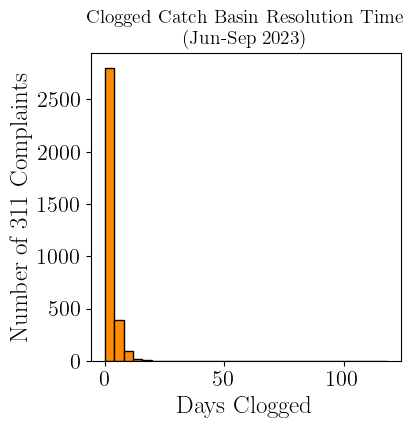

In [10]:
# Histogram of days clogged
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))

clogged_cb_311['days_clogged'].hist(bins=30, ax=ax, edgecolor='black', color='darkorange')
plt.xlabel('Days Clogged', fontsize=18)
plt.ylabel('Number of 311 Complaints', fontsize=18)
plt.title('Clogged Catch Basin Resolution Time\n(Jun-Sep 2023)', fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(False)

plt.savefig(f"{c.PAPER_PATH}/figures/clogged_cb_days_histogram.pdf", bbox_inches='tight', dpi=200)


In [11]:
# Clogged catch basin complaints by borough
if 'borough' in clogged_cb_311.columns:
    print("Clogged catch basin complaints by borough:")
    print(clogged_cb_311['borough'].value_counts())


Clogged catch basin complaints by borough:
borough
QUEENS           1252
BROOKLYN         1128
BRONX             362
STATEN ISLAND     354
MANHATTAN         246
Name: count, dtype: int64


In [ ]:
# Average resolution time statistics
city_median_resolution = clogged_cb_311['days_clogged'].median()
city_mean_resolution = clogged_cb_311['days_clogged'].mean()

print(f"City-wide resolution time statistics:")
print(f"  Median: {city_median_resolution:.1f} days")
print(f"  Mean: {city_mean_resolution:.1f} days")
print(f"\nThis median ({city_median_resolution:.1f} days) is used to impute resolution time")
print(f"for tracts that had no clogged catch basin complaints during Jun-Sep 2023.")
